In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F

In [2]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [3]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/hakula/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 10,
    "lr_factor": 0.8,
    "lr_delta": 7e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 150,
    "patience": 25,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2
}

In [4]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/hakula/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 10,
    "lr_factor": 0.8,
    "lr_delta": 7e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 150,
    "patience": 25,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2
}

In [5]:
torch.set_default_dtype(torch.float64)

In [6]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

df, spark = load_data(config)

x_cols = ['x1', 'x2', 'x3', 'x4']
y_cols = config["var_y"]
x_train = df["train"][x_cols]
y_train = df["train"][y_cols]
x_val = df["validate"][x_cols]
y_val = df["validate"][y_cols]
x_test = df["test"][x_cols]
y_test = df["test"][y_cols]

train_dataset = MyDataset(x_train, y_train, config)
val_dataset   = MyDataset(x_val, y_val, config)
test_dataset  = MyDataset(x_test, y_test, config)

# load the data into torch tensor batches
batch_size = config["batch_size"]
numworkers = 4 if get_device().type == 'cpu' else 0

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/04 04:41:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[]
['y5', 'y6']


In [7]:
model_path = "/home/hakula/qqzz4l-NN/models/skip-mini_a18ff108_30_12_5/a18ff108.best_weights.pt"

In [8]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # # plot all the scaled and real deltas
    # for c in scaled_delta_cname:
    #     make_error_plot(config, df_pred, col=c)
    # for c in delta_cname:
    #     make_error_plot(config, df_pred, col=c)
        
    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred


In [9]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)


In [21]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())

SkipModel(
  (input_layer): Sequential(
    (0): Linear(in_features=4, out_features=30, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=30, out_features=30, bias=True)
        (5): LeakyReLU(negative_slope=0.01)
        (6): Linear(in_features=30, out_features=30, bias=True)
        (7): LeakyReLU(negative_slope=0.01)
        (8): Linear(in_features=30, out_features=30, bias=True)
      )
    )
    (1): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
     

In [22]:
best_weights_path = model_path
model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

/tmp/ipykernel_2620844/3790447714.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if

<All keys matched successfully>

In [23]:
test_metrics, df_pred = test_model(model, test_loader, config)

In [24]:
test_metrics

{'r2': {'y5': 73.52059761068325,
  'y6': 65.11295003793356,
  'model': 99.9297257891863},
 'abs_score': {'y5': 98.81574443787352,
  'y6': 98.86503816909607,
  'model': 99.28962779988962}}

In [14]:
df5 = df_pred[['y5', 'y5_pred']].copy()

# compute the raw difference (residual)
df5['diff'] = df5['y5'] - df5['y5_pred']

# compute percent‐error delta
df5['delta_y5'] = df5['diff'] / df5['y5'] * 100

# show the first few rows
df5

,y5,y5_pred,diff,delta_y5
0,-174.455943,-173.914296,-0.541647,0.310478
1,152.387746,152.473722,-0.085975,-0.056419
2,63.641536,63.676865,-0.035329,-0.055512
3,223.437810,222.934899,0.502911,0.225079
4,171.113443,170.914612,0.198831,0.116199
...,...,...,...,...
499707,-60.256685,-60.530210,0.273525,-0.453933
499708,-15.112394,-15.098015,-0.014379,0.095145
499709,-6.717664,-6.715215,-0.002448,0.036447
499710,-11.152331,-11.170311,0.017980,-0.161222


In [15]:
pd.set_option('display.float_format', '{:.20f}'.format)
print(df5.sort_values('delta_y5', ascending=False)[0:10000])

                             y5                  y5_pred  \
232142   0.00040675833840175812  -0.05567288993243169060   
102917   0.00187065252345242072  -0.17013903084533588128   
385075  -0.00009976380529685969   0.00768692189819608629   
291531   0.00177707708326124703  -0.10050531616922619982   
193563   0.00088474016068129657  -0.04923330028043082507   
...                         ...                      ...   
427953  21.18297843664904434036  20.72701635545718090725   
71603   21.75820382199030689208  21.28988802988655493209   
25500  114.76835143404873917916 112.29826882539916255155   
253574   9.70365726355818303261   9.49481260815005079223   
215532  30.77977158465548868094  30.11732846494357573874   

                          diff                   delta_y5  
232142  0.05607964827083344872 13786.96955326904208050109  
102917  0.17200968336878830200  9195.17019929133311961778  
385075 -0.00778668570349294598  7805.12098583518127270509  
291531  0.10228239325248744684  5755.65

In [16]:
df5.reindex(df5['delta_y5'].abs().sort_values(ascending=False).index)[:10]

,y5,y5_pred,diff,delta_y5
337252,-0.00045730179277825300,-0.14381236123197971288,0.14335505943920145988,-31348.02043269372006761841
391015,-0.00036980753155546608,-0.10635752132699272110,0.10598771379543725502,-28660.23667761361866723746
232142,0.00040675833840175812,-0.05567288993243169060,0.05607964827083344872,13786.96955326904208050109
203308,12.70354875957127660513,1559.41116836233163667202,-1546.70761960276036006690,-12175.39798426340894366149
375389,-0.01690615492429969891,-1.92237850442045665744,1.90547234949615695854,-11270.87949937905250408221
102917,0.00187065252345242072,-0.17013903084533588128,0.17200968336878830200,9195.17019929133311961778
385075,-0.00009976380529685969,0.00768692189819608629,-0.00778668570349294598,7805.12098583518127270509
291531,0.00177707708326124703,-0.10050531616922619982,0.10228239325248744684,5755.65315741855101805413
193563,0.00088474016068129657,-0.04923330028043082507,0.05011804044111212164,5664.71859969808338064468
442975,-0.00582235087441063115,-0.26367165366521105874,0.25784930279080042759,-4428.61154115692625055090


# Eval code

# Error plots 

## h2 real and imaginary

In [25]:
# df_h2 = pd.read_csv('../models/skip-light-torch-4D-y5_y6-fe15fc3c--13-29-leaky_relu-1024-adam-exp-schedule-mse-val_mse-96.667286-99.840031/test-results-fe15fc3c-96.667286-99.840031.csv')
df_h2 = df_pred

In [26]:
df_h2

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.00013087069963800985,0.14743138560529800429,0.77435093348160000115,0.24598406901479599740,-5.16738797353955980896,5.23624844048620197157,-174.45594285713460180887,186.96362131953281959795,-5.16429611526124876519,5.23546555248864464716,-173.91429572730757513455,186.81652444412659974660,-0.05983406498879899338,-0.01495131498162128453,-0.31047788969309697560,-0.07867673634477899414
1,0.00054206535197799828,0.70544103001425895183,0.51185372012241703299,0.03413376665081500200,5.03296900500165200754,-5.06939689584949526591,152.38774629435093288521,-158.07835758861020281074,5.03352935877307139378,-5.07082069511837385534,152.47372178257134578416,-158.30501455656190046284,0.01113366227494187385,0.02808616681886374339,0.05641889870484950026,0.14338266882906217092
2,0.00075322412107680910,0.34823255008804998578,0.46095419738282000788,0.28326235474205402332,4.16885718209337952089,-4.18429982809803124866,63.64153637405618724188,-64.64752027230993292051,4.16940356299874803625,-4.18772719259779968581,63.67686492576879686567,-64.87290426871425097488,0.01310625146180113831,0.08191010779756531524,0.05551178322434638379,0.34863517650011915938
3,0.00086555568764487198,0.65990413015172100231,0.12348994223421899674,0.85235588138936801972,5.41359865290541364402,-5.48120501435531970458,223.43780993024719805362,-239.13590030554044574274,5.41135538071841892815,-5.47875827979326857076,222.93489912732761126790,-238.54906970079053962763,-0.04143772619329248730,-0.04463862518630696413,-0.22507864854054265846,-0.24539628052505760292
4,0.00090633229286470767,0.54791541922759201544,0.64952411402665799489,0.69303896421182198395,5.14815381263669191725,-5.18498179473675069318,171.11344315605572319328,-177.57019884275518961658,5.14699791106136395058,-5.18565142951428015294,170.91461189280008170499,-177.68981570346582543607,-0.02245273970817816475,0.01291489158571786609,-0.11619850526548465564,0.06736313947396142809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.85857387251268046935,0.08471328442450599960,0.16953363967766599263,0.45110424908873697492,-4.11507298461740678164,0.52421110696045147836,-60.25668489531697247230,0.68912578305207694562,-4.11952826894274259928,0.53524588116736437904,-60.53020970630920771782,0.70786812323952919002,0.10826744366357918259,2.10502487650369562999,0.45393272375907467442,2.71972702928688603308
499708,0.85865289663669686071,0.31579244829251301718,0.71322454939077795100,0.70977526538560198333,-2.77958876365855367396,-1.41910555150029504823,-15.11239358362512774647,-3.13342165351423229680,-2.77869596283546727022,-1.41951359683154820779,-15.09801484500171397940,-3.13510862107826238088,-0.03211988891159858056,0.02875369847026313513,-0.09514534242274960696,0.05383787279755650884
499709,0.85883764605769807865,0.60979391375153502164,0.21269961700672598837,0.33635187117229398135,-2.04351166450979970790,-1.28735804635899331316,-6.71766351329699773487,-2.62320156920509406362,-2.04319436658137032481,-1.28521442418212061831,-6.71521510311019564909,-2.61544311254086503382,-0.01552709162076140910,-0.16651328532380363368,-0.03644734783091893582,-0.29576288590663146749
499710,0.85884150966854777565,0.43219819200168502205,0.13024657446619600232,0.72971293078026000511,-2.49752098458943283532,-1.49189219886032953255,-11.15233077338620937269,-3.44549933442544897844,-2.49899944159571862912,-1.49172121481095398821,-11.17031076000431077944,-3.44473928992734723664,0.05919698034204253639,-0.01146088500939683626,0.16122178388941471594,-0.02205905223976722257


In [27]:
df_h2.describe()

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
count,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000
mean,0.49925700527143107577,0.49946930487487523065,0.49959831168449431171,0.49919920875870060772,-0.75457357015712056558,-2.86833747712783049266,-16.25609837180594752226,-61.42310969016146060540,-0.75764465252505064363,-2.86794446491052390513,-16.39783897874300677699,-60.56301036107122115482,0.03310203183300984564,0.11331180075248982464,0.15588241530658586420,0.07207778130740262468
std,0.28840179849242147947,0.28869124178696292660,0.28880734299482851979,0.28830808721535133854,3.55897325407550813026,2.63359049616745410916,247.09244549021448733583,428.19222186217757553095,3.55891927246756178960,2.63441248626083801554,218.77960573156926216143,273.01283911906239154632,65.45094021505744308342,105.53086934542679387050,72.81586790637889805566,114.07169225294437353568
min,0.00000014615929290980,0.00000367488420800000,0.00000149422516200000,0.00000000188715600000,-10.78750334864700199944,-11.66620644401901252252,-48411.01707920023909537122,-116564.24568519067543093115,-10.02155135289173060187,-10.30002572194683985174,-22505.31809263961622491479,-29732.38364356886813766323,-13422.25718954112016945146,-7593.91351824236153333914,-13786.96955326904208050109,-14550.65861711294746783096
25%,0.24945223390406567887,0.24947608692559200549,0.24909028326087523375,0.24961780091905599877,-3.25230304421465010734,-4.73263548741000406039,-24.84980465904642699115,-112.59454518659177324480,-3.25449898196809117579,-4.73311669489298303404,-24.90663159241908886088,-112.64922088748907924582,-0.03107037795790537973,-0.05197259893823942545,-0.11514551893732703769,-0.19524574091872032300
50%,0.49907971771260983829,0.49964960652232598415,0.49989675755400297952,0.49843940292516353274,-2.40014991585802039964,-3.73010536789759683529,-10.02482905376304245237,-40.68350004174989464900,-2.40165409818843134104,-3.73058937086486874790,-10.04142488540205135905,-40.70367985989211234710,0.03387474920595369421,0.00409990146292229553,0.11371352843692902890,0.01512181560241176656
75%,0.74849174774416449285,0.74942372292592418503,0.74936844710294003846,0.74833402423672923387,3.49257307531045535498,-1.83002036293146663759,31.87041704543874942601,-5.23401360010504301812,3.49106380068687727203,-1.82859660609365737294,31.82084397903803107965,-5.22514420123125411521,0.09859028751387857725,0.06475283325048983296,0.33459406501102750831,0.22932035346879958704
max,0.99999424527251590256,0.99999788764426100762,0.99999874299348801010,0.99999812827165501794,10.15148820541972796150,7.79584836113105250632,25628.21537676935622585006,2429.49048374962012530887,8.62661312589197493139,7.32107998881419508308,5577.15371899398905952694,1510.83585420761710338411,29289.25289316150519880466,71800.02559877821477130055,31348.02043269372006761841,74061.53128616600588429719


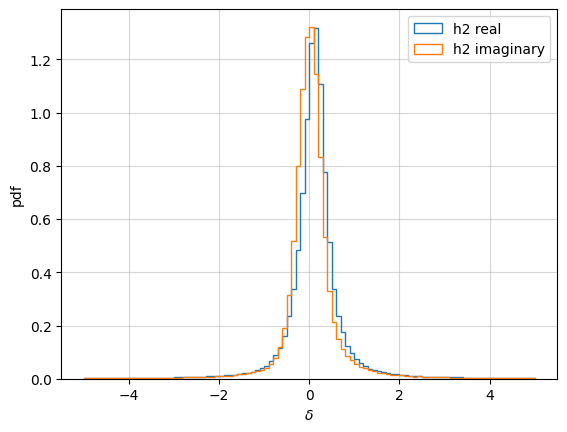

In [28]:
plt.hist(df_h2[abs(df_h2.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='h2 real', density=True)
plt.hist(df_h2[abs(df_h2.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='h2 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

In [29]:
df_h2[abs(df_h2.scaled_delta_y6) < 5].scaled_delta_y6

0        -0.01495131498162128453
1         0.02808616681886374339
2         0.08191010779756531524
3        -0.04463862518630696413
4         0.01291489158571786609
                   ...          
499707    2.10502487650369562999
499708    0.02875369847026313513
499709   -0.16651328532380363368
499710   -0.01146088500939683626
499711   -0.06420185914879487921
Name: scaled_delta_y6, Length: 495460, dtype: float64

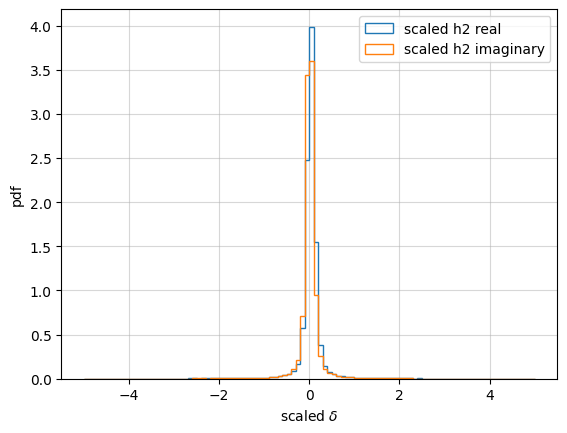

In [30]:
plt.hist(df_h2[abs(df_h2.scaled_delta_y5) < 5].scaled_delta_y5, bins=100, histtype='step', label='scaled h2 real', density=True)
plt.hist(df_h2[abs(df_h2.scaled_delta_y6) < 5].scaled_delta_y6, bins=100, histtype='step', label='scaled h2 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'scaled $\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()